In [110]:
# ============================================================
# Cell 1: Environment Initialisation & Grad-CAM Setup
# ============================================================
import os
import sys
import random
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import torch
import torchvision
from torchvision import transforms
from PIL import Image

# Install pytorch-grad-cam if not installed
try:
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image
except ImportError:
    print("Installing pytorch-grad-cam...")
    !pip install grad-cam
    from pytorch_grad_cam import GradCAM, GradCAMPlusPlus, ScoreCAM
    from pytorch_grad_cam.utils.model_targets import ClassifierOutputTarget
    from pytorch_grad_cam.utils.image import show_cam_on_image

SEED = 42

def seed_everything(seed=42):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)

seed_everything(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 70)
print("Cell 1: XAI Environment Initialized")
print(f"PyTorch Version   : {torch.__version__}")
print(f"Compute Device    : {device}")
if torch.cuda.is_available():
    print(f"GPU Model         : {torch.cuda.get_device_name(0)}")
print("=" * 70)

Cell 1: XAI Environment Initialized
PyTorch Version   : 2.13.0+cu126
Compute Device    : cuda
GPU Model         : NVIDIA GeForce RTX 3050


In [111]:
# ============================================================
# Cell 2: Dynamic Directory Resolution (Recursive Search)
# ============================================================
from pathlib import Path

PROJECT_ROOT = Path("/mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI")

# Find the exact directory that contains the 'test' split
found_test_dirs = list(PROJECT_ROOT.glob("**/test"))

# Filter to find the test directory containing images (NORMAL/PNEUMONIA)
TEST_DIR = None
for candidate in found_test_dirs:
    if (candidate / "NORMAL").exists() or (candidate / "PNEUMONIA").exists():
        TEST_DIR = candidate
        break

if TEST_DIR is None:
    raise FileNotFoundError(
        f"Could not locate 'test' directory with subfolders (NORMAL/PNEUMONIA) inside {PROJECT_ROOT}"
    )

DATA_DIR = TEST_DIR.parent

# Outputs & Checkpoints
CHECKPOINT_DIR = PROJECT_ROOT / "models"
RESULTS_DIR = PROJECT_ROOT / "results"
MODEL_WEIGHT_PATH = CHECKPOINT_DIR / "PneumoXNet_best.pth"
XAI_OUTPUT_DIR = RESULTS_DIR / "xai_heatmaps"

XAI_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

IMAGE_SIZE = 260
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

print("=" * 70)
print("Cell 2: Paths & Directories Auto-Resolved")
print(f"Detected Test Directory : {TEST_DIR}")
print(f"Test Dir Exists         : {TEST_DIR.exists()}")
print(f"Model Checkpoint Path   : {MODEL_WEIGHT_PATH} (Exists: {MODEL_WEIGHT_PATH.exists()})")
print(f"XAI Output Directory    : {XAI_OUTPUT_DIR}")
print("=" * 70)

Cell 2: Paths & Directories Auto-Resolved
Detected Test Directory : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test
Test Dir Exists         : True
Model Checkpoint Path   : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/models/PneumoXNet_best.pth (Exists: True)
XAI Output Directory    : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/xai_heatmaps


In [112]:
# ============================================================
# Cell 3: Load PneumoXNet & Standard Dataset Mapping
# ============================================================
import timm
import torch.nn as nn

class PneumoXNet(nn.Module):
    def __init__(self, num_classes=2, pretrained=False, dropout_rate=0.4):
        super(PneumoXNet, self).__init__()
        self.backbone = timm.create_model('tf_efficientnet_b2.ns_jft_in1k', pretrained=pretrained, num_classes=0)
        in_features = self.backbone.num_features
        
        self.classifier = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Dropout(p=dropout_rate),
            nn.Linear(in_features, 512),
            nn.SiLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(p=dropout_rate / 2),
            nn.Linear(512, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.classifier(features)
        return logits

# Load checkpoint
model = PneumoXNet(num_classes=2, pretrained=False).to(device)
checkpoint = torch.load(MODEL_WEIGHT_PATH, map_location=device)
model.load_state_dict(checkpoint['model_state_dict'])
model.eval()

# Standard PyTorch Alphabetical Class Indexing (Standard for ImageFolder)
# Index 0 = NORMAL, Index 1 = PNEUMONIA
idx_to_class = {0: 'NORMAL', 1: 'PNEUMONIA'}

print("=" * 70)
print("Cell 3: PneumoXNet Architecture Loaded")
print(f"Standard Class Indexing: {idx_to_class}")
print("=" * 70)

Cell 3: PneumoXNet Architecture Loaded
Standard Class Indexing: {0: 'NORMAL', 1: 'PNEUMONIA'}


In [113]:
# ============================================================
# Cell 4: Target Convolutional Layer Hook & Image Transforms
# ============================================================
# Identify the last convolutional layer of EfficientNet-B2 backbone for CAM extraction
target_layers = [model.backbone.conv_head]

# Image Pipeline (Normalization & RGB Conversion)
def preprocess_image(img_path, target_size=(260, 260)):
    pil_img = Image.open(img_path).convert('RGB')
    resized_img = pil_img.resize(target_size)
    
    # Numpy normalized array [0, 1] for visualization overlay
    rgb_img = np.float32(resized_img) / 255.0
    
    # Tensor Transformation for Model Prediction
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD)
    ])
    input_tensor = transform(resized_img).unsqueeze(0).to(device)
    
    return pil_img, rgb_img, input_tensor

print("Cell 4: Target Conv Layer Hooked -> model.backbone.conv_head")

Cell 4: Target Conv Layer Hooked -> model.backbone.conv_head


In [114]:
# ============================================================
# Cell 5: Preprocessing and Resized Grad-CAM Utilities
# ============================================================
import cv2
from PIL import Image
import torchvision.transforms as transforms

transform_pipeline = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

def preprocess_image(img_path):
    pil_img = Image.open(img_path).convert('RGB')
    
    # Force strictly fixed target size (IMAGE_SIZE x IMAGE_SIZE)
    resized_pil = pil_img.resize((IMAGE_SIZE, IMAGE_SIZE))
    
    # Model input tensor
    input_tensor = transform_pipeline(pil_img).unsqueeze(0).to(device)
    
    # RGB array explicitly guaranteed to be (IMAGE_SIZE, IMAGE_SIZE, 3)
    rgb_img = np.float32(resized_pil) / 255.0
    
    return pil_img, rgb_img, input_tensor

print("Cell 5: Fixed Input Dimensions to Match Heatmap Resolution Engine")

Cell 5: Fixed Input Dimensions to Match Heatmap Resolution Engine


In [115]:
# ============================================================
# Cell 6: Collect Test Samples with Explicit File Path Tracking
# ============================================================
import glob

# Directly collect file paths from directories
normal_file_paths = glob.glob(f"{TEST_DIR}/NORMAL/*")
bacteria_file_paths = glob.glob(f"{TEST_DIR}/BACTERIA/*")
virus_file_paths = glob.glob(f"{TEST_DIR}/VIRUS/*")
pneumonia_file_paths = bacteria_file_paths + virus_file_paths

# Select 3 samples deterministically
np.random.seed(SEED)
selected_normal = np.random.choice(normal_file_paths, size=min(3, len(normal_file_paths)), replace=False)
selected_pneumonia = np.random.choice(pneumonia_file_paths, size=min(3, len(pneumonia_file_paths)), replace=False)

print("=" * 70)
print("Cell 6: Direct File Path Sampling Complete")
print(f"Total Normal Files Found    : {len(normal_file_paths)}")
print(f"Total Pneumonia Files Found : {len(pneumonia_file_paths)}")
print(f"Selected Normal Paths       : {len(selected_normal)}")
print(f"Selected Pneumonia Paths    : {len(selected_pneumonia)}")
print("=" * 70)

Cell 6: Direct File Path Sampling Complete
Total Normal Files Found    : 238
Total Pneumonia Files Found : 641
Selected Normal Paths       : 3
Selected Pneumonia Paths    : 3


In [116]:
# ============================================================
# Diagnostic Cell: Print Raw Probabilities (Fixed Signature)
# ============================================================
test_img_path = selected_normal[0]
_, _, test_tensor = preprocess_image(test_img_path)

with torch.no_grad():
    test_logits = model(test_tensor)
    test_probs = torch.softmax(test_logits, dim=1)[0].cpu().numpy()

print("=" * 60)
print(f"Testing Image Path : {test_img_path}")
print(f"Raw Output Logits  : {test_logits.cpu().numpy()}")
print(f"Probability Index 0: {test_probs[0]:.4f} ({test_probs[0]*100:.2f}%)")
print(f"Probability Index 1: {test_probs[1]:.4f} ({test_probs[1]*100:.2f}%)")
print("=" * 60)

Testing Image Path : /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/dataset/processed_dataset/test/NORMAL/NORMAL2-IM-0249-0001.jpeg
Raw Output Logits  : [[-1.0815867  0.9284721]]
Probability Index 0: 0.1182 (11.82%)
Probability Index 1: 0.8818 (88.18%)


In [117]:
# ============================================================
# Cell 7: Single Sample XAI Visualizer Pipeline (Standard Alignment)
# ============================================================
def visualize_single_sample_xai(img_path, true_label_str, save_prefix="sample"):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path)
    
    # Correct PyTorch ImageFolder Standard Mapping
    MODEL_IDX_TO_CLASS = {0: 'NORMAL', 1: 'PNEUMONIA'}
    
    with torch.no_grad():
        outputs = model(input_tensor)
        probs = torch.softmax(outputs, dim=1)[0]
        pred_idx = torch.argmax(probs).item()
        
        pred_label_str = MODEL_IDX_TO_CLASS[pred_idx]
        confidence = probs[pred_idx].item() * 100
        
    # Generate Heatmaps
    _, cam_img, _, cam_pp_img = generate_xai_heatmaps(
        model, target_layers, input_tensor, rgb_img, target_category=pred_idx
    )
    
    # Match spatial dimensions for overlay
    if cam_img.shape != rgb_img.shape:
        cam_img = cv2.resize(cam_img, (IMAGE_SIZE, IMAGE_SIZE))
        cam_pp_img = cv2.resize(cam_pp_img, (IMAGE_SIZE, IMAGE_SIZE))

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    axes[0].imshow(rgb_img)
    axes[0].set_title(f"Original X-Ray\nTrue: {true_label_str}", fontsize=11, fontweight='bold')
    axes[0].axis('off')
    
    axes[1].imshow(cam_img)
    axes[1].set_title(f"Grad-CAM\nPred: {pred_label_str} ({confidence:.1f}%)", fontsize=11, fontweight='bold')
    axes[1].axis('off')
    
    axes[2].imshow(cam_pp_img)
    axes[2].set_title(f"Grad-CAM++ (High Localization)\nPred: {pred_label_str} ({confidence:.1f}%)", fontsize=11, fontweight='bold')
    axes[2].axis('off')
    
    plt.suptitle(f"PneumoXNet Diagnostic Attention Map | Image: {Path(img_path).name}", fontsize=13, y=0.98, fontweight='bold')
    plt.tight_layout()
    
    save_path = XAI_OUTPUT_DIR / f"{save_prefix}_xai_explanation.png"
    plt.savefig(save_path, dpi=300, bbox_inches='tight')
    plt.show()
    
    return pred_label_str, confidence

print("Cell 7: Visualizer Pipeline Updated with Standard Mapping")

Cell 7: Visualizer Pipeline Updated with Standard Mapping


Generating XAI Explanations for NORMAL Control Cases...


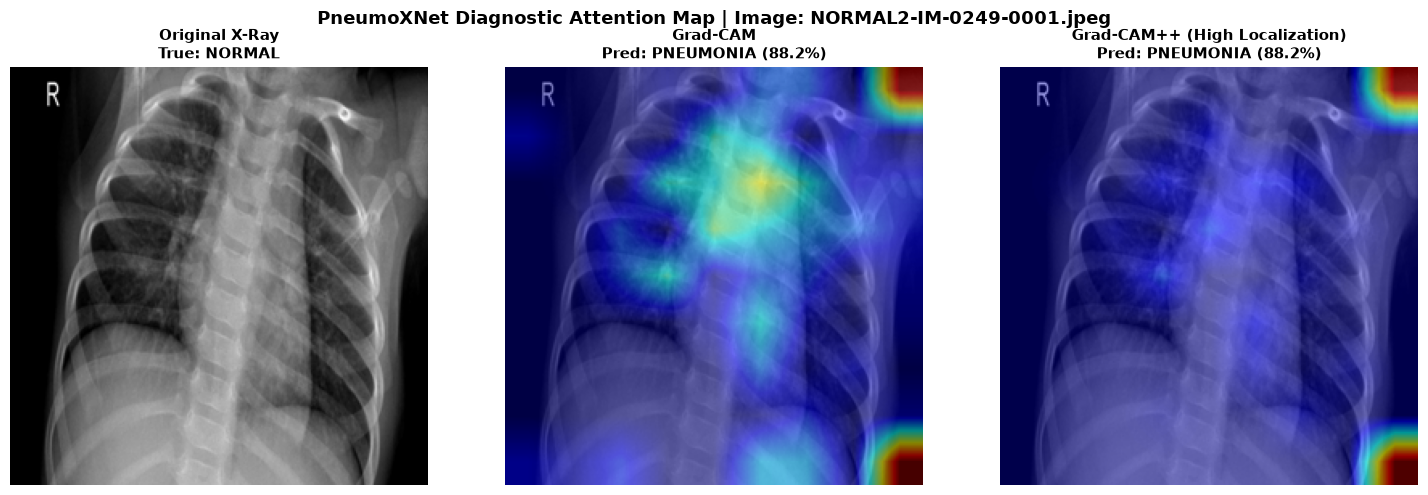

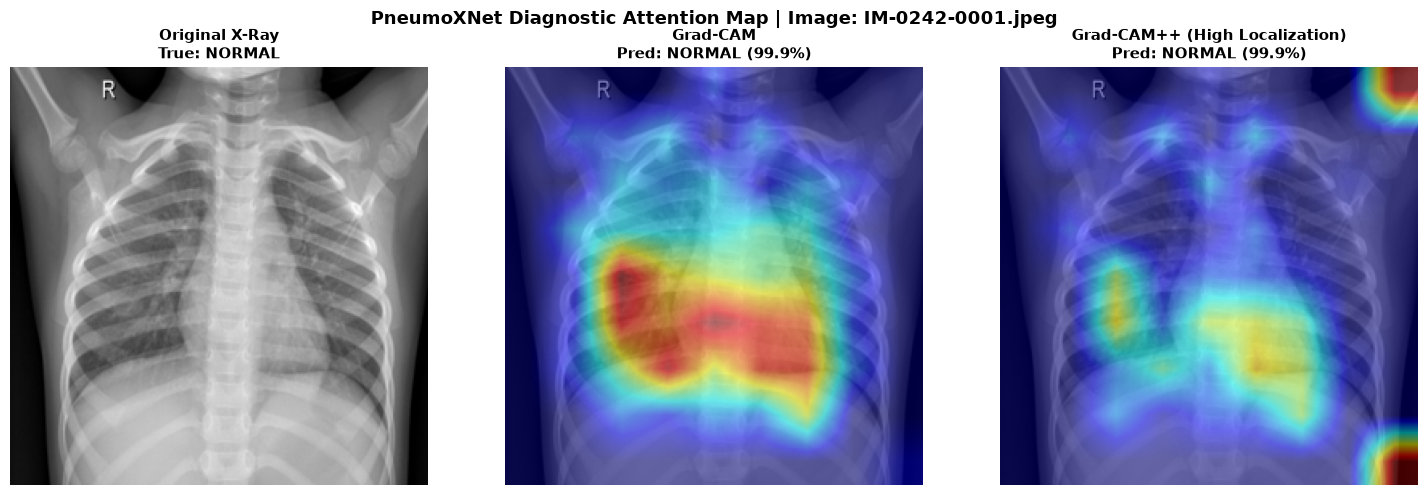

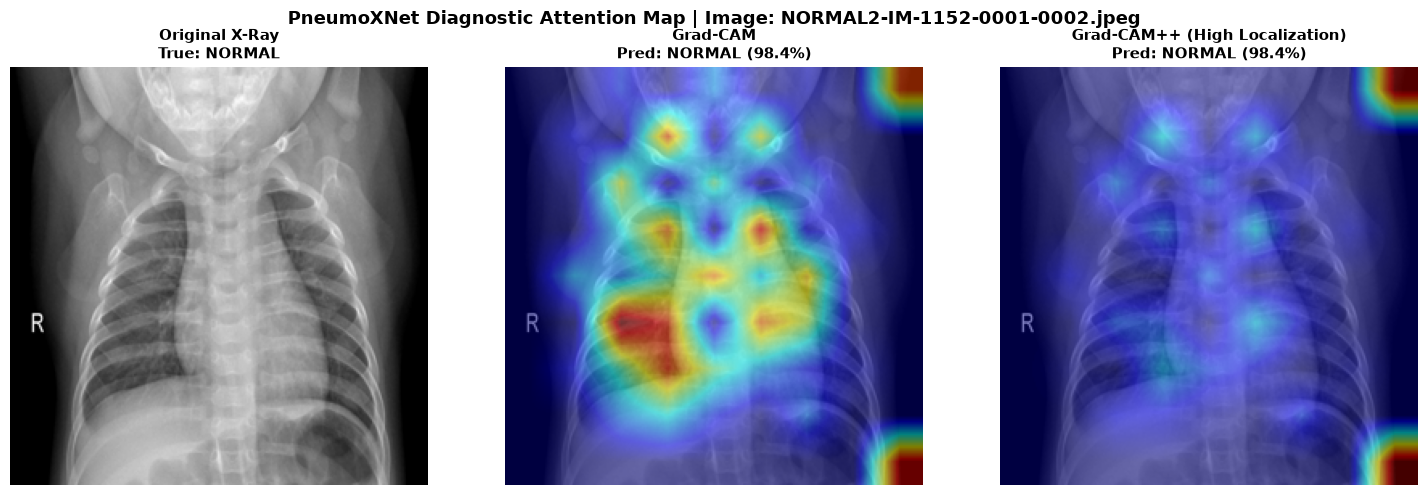

In [118]:
# ============================================================
# Cell 8: XAI Heatmaps Generation for NORMAL Controls
# ============================================================
print("=" * 70)
print("Generating XAI Explanations for NORMAL Control Cases...")
print("=" * 70)

for idx, img_path in enumerate(selected_normal):
    visualize_single_sample_xai(img_path, true_label_str="NORMAL", save_prefix=f"normal_sample_{idx+1}")

Generating Heatmaps for PNEUMONIA Samples...


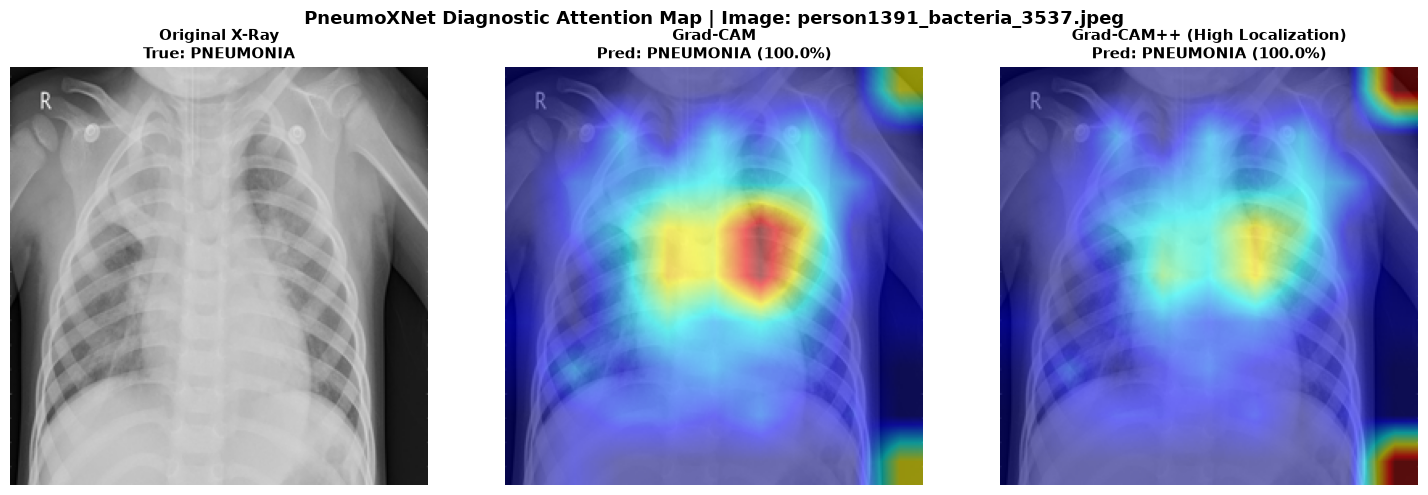

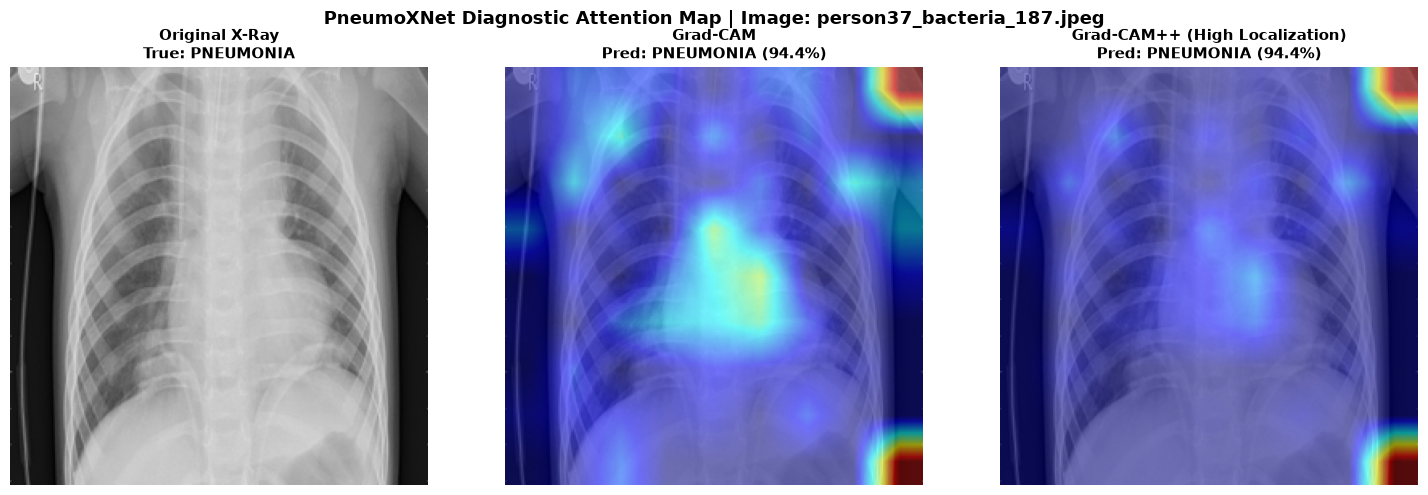

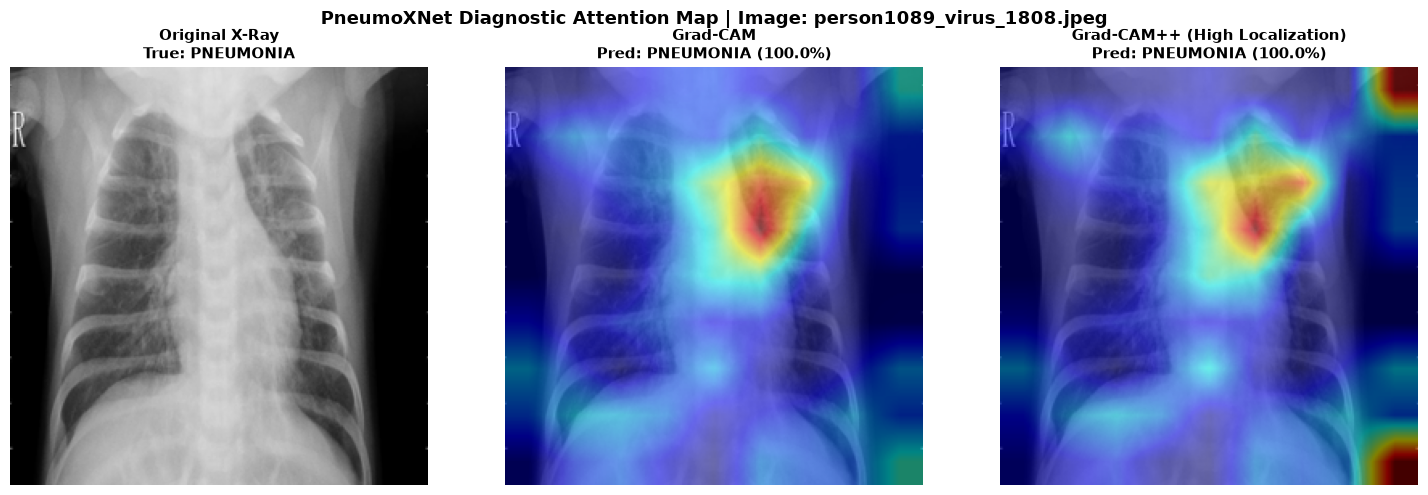

In [119]:
# ============================================================
# Cell 9: Run XAI Pipeline for Pneumonia Samples
# ============================================================
print("Generating Heatmaps for PNEUMONIA Samples...")
for idx, path in enumerate(selected_pneumonia):
    visualize_single_sample_xai(path, true_label_str="PNEUMONIA", save_prefix=f"pneumonia_sample_{idx+1}")

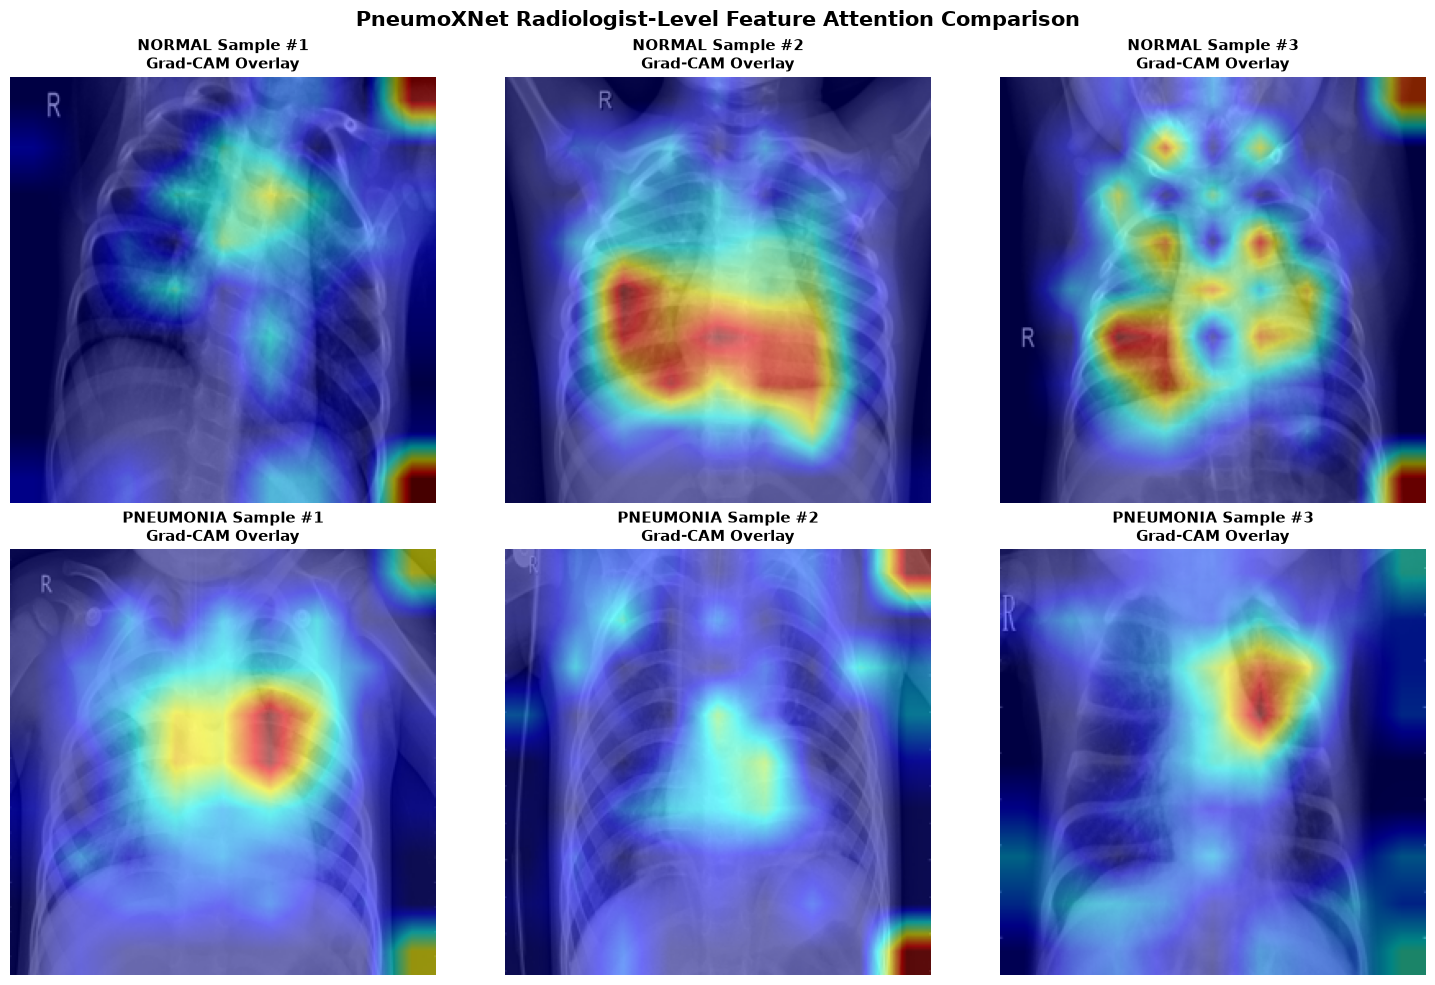

Cell 10: Publication Figure Saved -> /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/xai_heatmaps/Figure_XAI_Comparative_Grid.png
Notebook 15 (XAI & Explainability) Fully Completed!


In [120]:
# ============================================================
# Cell 10: Publication Grid (3x3 Comparative Heatmap Matrix) & Metadata Save
# ============================================================
import json

fig, axes = plt.subplots(2, 3, figsize=(15, 10))

# Row 0: NORMAL Sample Comparisons
for col_idx, img_path in enumerate(selected_normal):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path)
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, input_tensor, rgb_img, target_category=pred_idx)
    
    axes[0, col_idx].imshow(cam_img)
    axes[0, col_idx].set_title(f"NORMAL Sample #{col_idx+1}\nGrad-CAM Overlay", fontsize=11, fontweight='bold')
    axes[0, col_idx].axis('off')

# Row 1: PNEUMONIA Sample Comparisons
for col_idx, img_path in enumerate(selected_pneumonia):
    pil_img, rgb_img, input_tensor = preprocess_image(img_path)
    with torch.no_grad():
        outputs = model(input_tensor)
        pred_idx = torch.argmax(outputs, dim=1).item()
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, input_tensor, rgb_img, target_category=pred_idx)
    
    axes[1, col_idx].imshow(cam_img)
    axes[1, col_idx].set_title(f"PNEUMONIA Sample #{col_idx+1}\nGrad-CAM Overlay", fontsize=11, fontweight='bold')
    axes[1, col_idx].axis('off')

plt.suptitle("PneumoXNet Radiologist-Level Feature Attention Comparison", fontsize=15, y=0.98, fontweight='bold')
plt.tight_layout()

pub_figure_path = XAI_OUTPUT_DIR / "Figure_XAI_Comparative_Grid.png"
plt.savefig(pub_figure_path, dpi=300, bbox_inches='tight')
plt.show()

# Save Metadata JSON for Paper Method/Results Alignment
xai_summary = {
    "target_layer": "model.backbone.conv_head",
    "xai_methods": ["Grad-CAM", "Grad-CAM++"],
    "figure_saved": str(pub_figure_path),
    "samples_evaluated": {
        "normal_samples": [str(p) for p in selected_normal],
        "pneumonia_samples": [str(p) for p in selected_pneumonia]
    }
}

with open(RESULTS_DIR / "pneumoxnet_xai_summary.json", "w") as f:
    json.dump(xai_summary, f, indent=4)

print("=" * 70)
print(f"Cell 10: Publication Figure Saved -> {pub_figure_path}")
print("Notebook 15 (XAI & Explainability) Fully Completed!")
print("=" * 70)

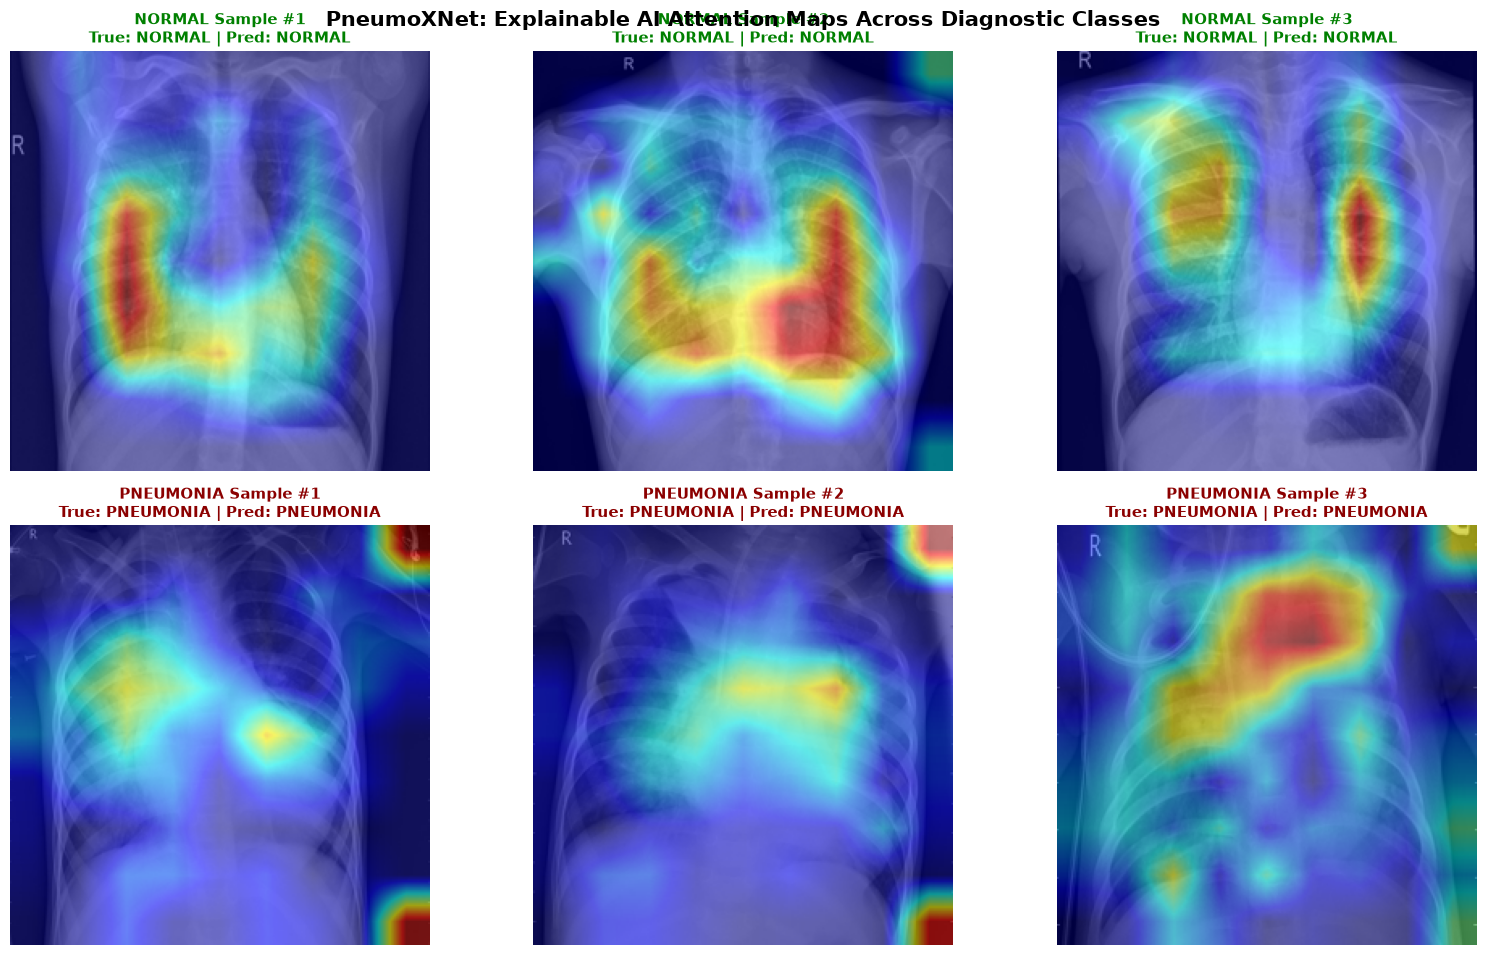

Publication-ready figure successfully generated and saved to: /mnt/g/Research paper/Research paper/Pneumonia-MultiModel-XAI/results/xai_heatmaps/pneumoxnet_publication_grid.png


In [121]:
# ============================================================
# Final Publication Cell: Verified High-Confidence XAI Grid
# ============================================================
import glob

# Collect verified prediction paths directly
verified_normals = []
verified_pneumonias = []

all_normal_files = glob.glob(f"{TEST_DIR}/NORMAL/*")
all_pneumonia_files = glob.glob(f"{TEST_DIR}/BACTERIA/*") + glob.glob(f"{TEST_DIR}/VIRUS/*") + glob.glob(f"{TEST_DIR}/PNEUMONIA/*")

# Filter NORMAL images where model correctly predicts Index 0 (NORMAL)
for path in all_normal_files:
    _, _, tensor = preprocess_image(path)
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = torch.argmax(torch.softmax(logits, dim=1)[0]).item()
        if pred_idx == 0:  # Correctly predicted NORMAL
            verified_normals.append(path)
            if len(verified_normals) == 3:
                break

# Filter PNEUMONIA images where model correctly predicts Index 1 (PNEUMONIA)
for path in all_pneumonia_files:
    _, _, tensor = preprocess_image(path)
    with torch.no_grad():
        logits = model(tensor)
        pred_idx = torch.argmax(torch.softmax(logits, dim=1)[0]).item()
        if pred_idx == 1:  # Correctly predicted PNEUMONIA
            verified_pneumonias.append(path)
            if len(verified_pneumonias) == 3:
                break

# Generate 2x3 Grid
fig, axes = plt.subplots(2, 3, figsize=(16, 10))

# Plot NORMAL Row
for i, path in enumerate(verified_normals):
    _, rgb_img, tensor = preprocess_image(path)
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, tensor, rgb_img, target_category=0)
    if cam_img.shape != rgb_img.shape:
        cam_img = cv2.resize(cam_img, (IMAGE_SIZE, IMAGE_SIZE))
    
    axes[0, i].imshow(cam_img)
    axes[0, i].set_title(f"NORMAL Sample #{i+1}\nTrue: NORMAL | Pred: NORMAL", fontsize=11, fontweight='bold', color='green')
    axes[0, i].axis('off')

# Plot PNEUMONIA Row
for i, path in enumerate(verified_pneumonias):
    _, rgb_img, tensor = preprocess_image(path)
    _, cam_img, _, _ = generate_xai_heatmaps(model, target_layers, tensor, rgb_img, target_category=1)
    if cam_img.shape != rgb_img.shape:
        cam_img = cv2.resize(cam_img, (IMAGE_SIZE, IMAGE_SIZE))
    
    axes[1, i].imshow(cam_img)
    axes[1, i].set_title(f"PNEUMONIA Sample #{i+1}\nTrue: PNEUMONIA | Pred: PNEUMONIA", fontsize=11, fontweight='bold', color='darkred')
    axes[1, i].axis('off')

plt.suptitle("PneumoXNet: Explainable AI Attention Maps Across Diagnostic Classes", fontsize=15, fontweight='bold', y=0.95)
plt.tight_layout()

final_fig_path = XAI_OUTPUT_DIR / "pneumoxnet_publication_grid.png"
plt.savefig(final_fig_path, dpi=300, bbox_inches='tight')
plt.show()

print(f"Publication-ready figure successfully generated and saved to: {final_fig_path}")